In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

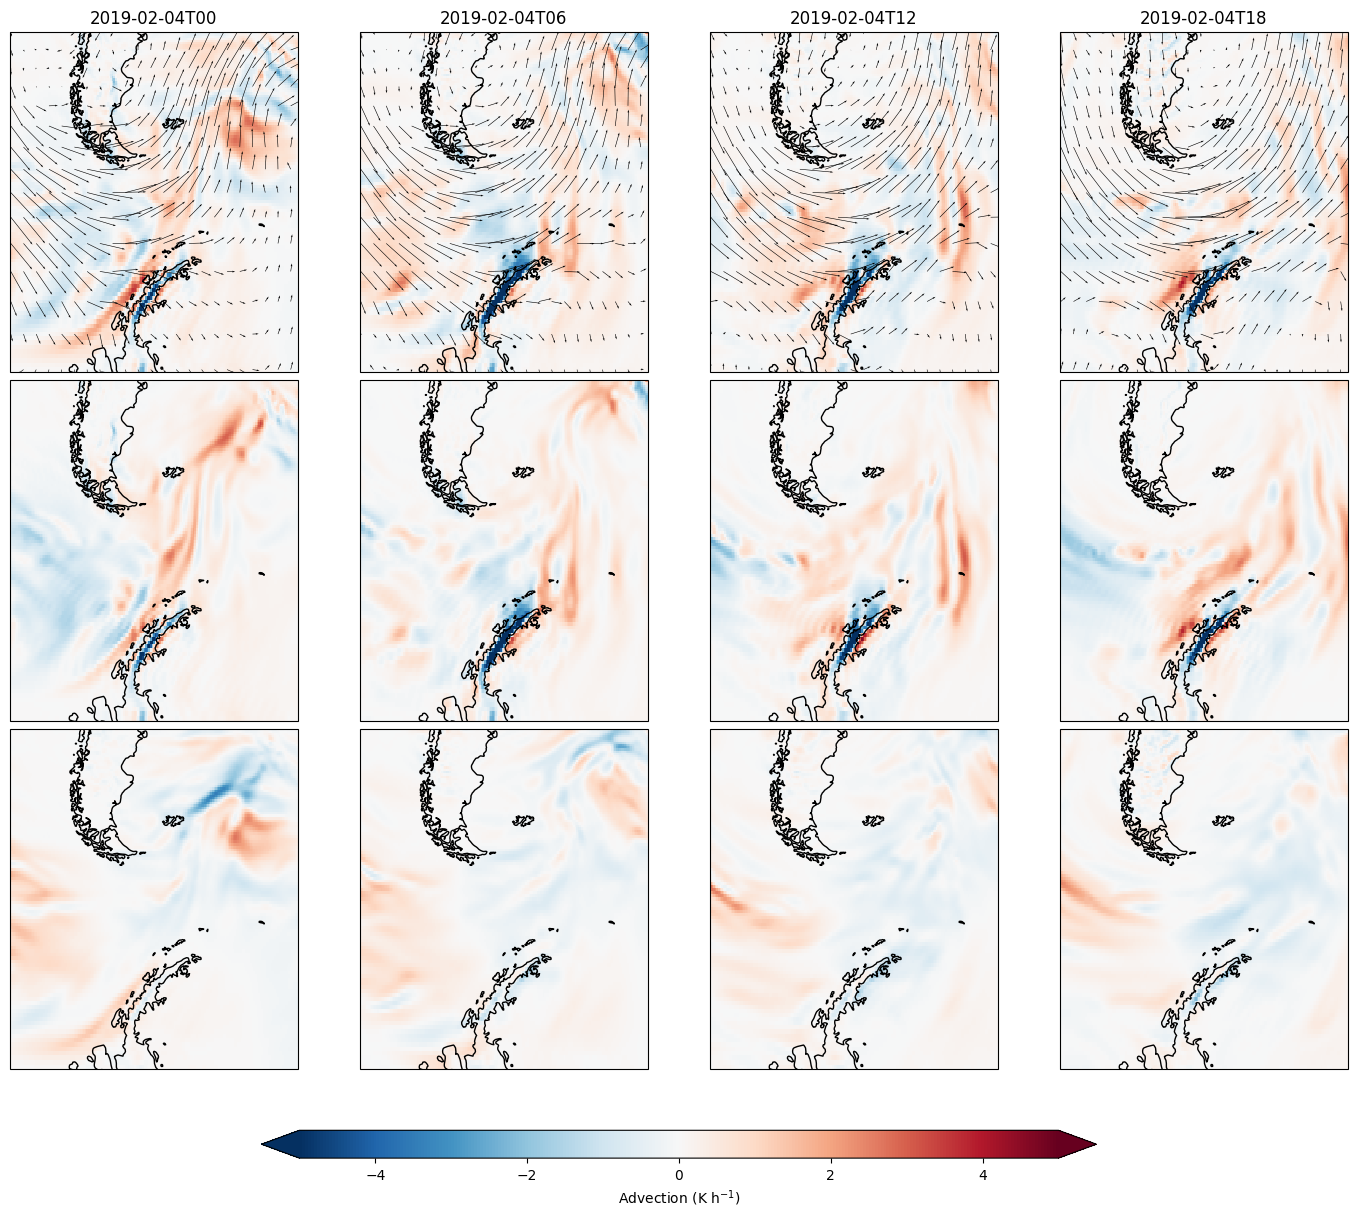

In [13]:
filename = "/home/lacrio/DATA/term_cal/res_new_700/era5_t_uvw_20190130_20190209_thermo_budget.nc"
ds = xr.open_dataset(filename) * 3600

filename = "/home/lacrio/DATA/term_cal/data_700/era5_t_uvw_20190130_20190209.nc"
ds_uv = xr.open_dataset(filename).sel(pressure_level=700)

date_sel = '2019-02-04'
times_h = [0,6,12,18]
# Select your day and 6-hourly times
adv_h = ds.sel(valid_time=date_sel)['adv_h']
adv_6h = adv_h.sel(valid_time=adv_h.valid_time.dt.hour.isin(times_h))

adv_x = ds.sel(valid_time=date_sel)['adv_x']
adv_x_6h = adv_x.sel(valid_time=adv_x.valid_time.dt.hour.isin(times_h))

adv_y = ds.sel(valid_time=date_sel)['adv_y']
adv_y_6h = adv_y.sel(valid_time=adv_y.valid_time.dt.hour.isin(times_h))

uv = ds_uv.sel(valid_time=date_sel)[['u','v']] 
uv_6h  = uv.sel(valid_time=uv.valid_time.dt.hour.isin(times_h))


# ---- FIX symmetric color limits ----
vmax = 5
vmin = -vmax

import numpy as np

# ---- Create subplots with projection ----
fig, axes = plt.subplots(
    3, 4, figsize=(14,12),
    subplot_kw={"projection": ccrs.Mercator()},
    constrained_layout=True
)

# ---- Loop por columnas (tiempo) ----
for i in range(4):

    # =====================
    # Fila 1: adv_h
    # =====================
    ax = axes[0, i]
    im = adv_6h.isel(valid_time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    
    ax.coastlines()
    
    # --- VECTORES ---
    skip = 8
    u_plot = uv_6h['u'].isel(valid_time=i)[::skip, ::skip]
    v_plot = uv_6h['v'].isel(valid_time=i)[::skip, ::skip]
    
    ax.quiver(
        u_plot.longitude.values,
        u_plot.latitude.values,
        u_plot.values,
        v_plot.values,
        transform=ccrs.PlateCarree(),
        scale=300,
        width=0.002
    )

    time_str = str(adv_6h.valid_time.values[i])[:13]
    ax.set_title(time_str)

    # =====================
    # Fila 2: adv_x
    # =====================
    ax = axes[1, i]
    adv_x_6h.isel(valid_time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title('')
    # =====================
    # Fila 3: adv_y
    # =====================
    ax = axes[2, i]
    adv_y_6h.isel(valid_time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title('')
# ---- Labels de filas ----
axes[0,0].set_ylabel("adv_h", fontsize=11)
axes[1,0].set_ylabel("adv_x", fontsize=11)
axes[2,0].set_ylabel("adv_y", fontsize=11)

# ---- One shared colorbar ----
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    pad=0.05,
    shrink=0.6,
    aspect=30,
    extend='both'
)
cbar.set_label("Advection (K h$^{-1}$)")

plt.show()

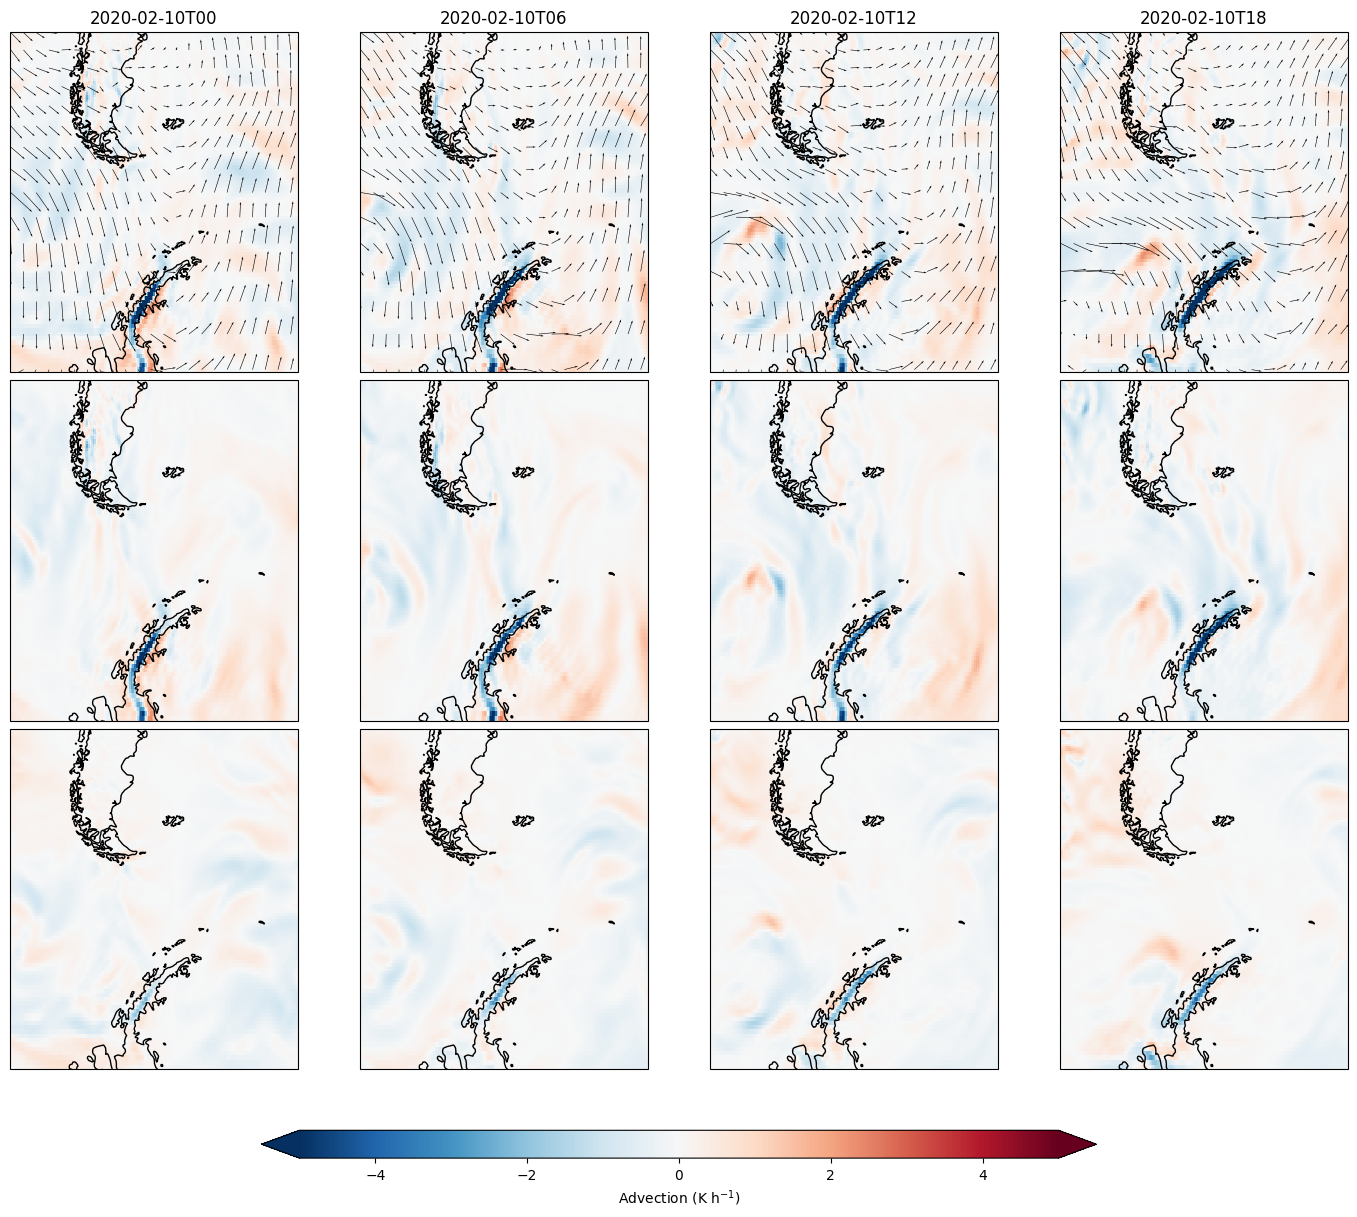

In [14]:
filename = "/home/lacrio/DATA/term_cal/res_new_700/era5_t_uvw_20200205_20200215_thermo_budget.nc"
ds = xr.open_dataset(filename) * 3600

filename = "/home/lacrio/DATA/term_cal/data_700/era5_t_uvw_20200205_20200215.nc"
ds_uv = xr.open_dataset(filename).sel(pressure_level=700)

date_sel = '2020-02-10'
times_h = [0,6,12,18]

# Select your day and 6-hourly times
adv_h = ds.sel(valid_time=date_sel)['adv_h']
adv_6h = adv_h.sel(valid_time=adv_h.valid_time.dt.hour.isin(times_h))

adv_x = ds.sel(valid_time=date_sel)['adv_x']
adv_x_6h = adv_x.sel(valid_time=adv_x.valid_time.dt.hour.isin(times_h))

adv_y = ds.sel(valid_time=date_sel)['adv_y']
adv_y_6h = adv_y.sel(valid_time=adv_y.valid_time.dt.hour.isin(times_h))

uv = ds_uv.sel(valid_time=date_sel)[['u','v']] 
uv_6h  = uv.sel(valid_time=uv.valid_time.dt.hour.isin(times_h))


# ---- FIX symmetric color limits ----
vmax = 5
vmin = -vmax

import numpy as np

# ---- Create subplots with projection ----
fig, axes = plt.subplots(
    3, 4, figsize=(14,12),
    subplot_kw={"projection": ccrs.Mercator()},
    constrained_layout=True
)

# ---- Loop por columnas (tiempo) ----
for i in range(4):

    # =====================
    # Fila 1: adv_h
    # =====================
    ax = axes[0, i]
    im = adv_6h.isel(valid_time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    
    ax.coastlines()
    
    # --- VECTORES ---
    skip = 8
    u_plot = uv_6h['u'].isel(valid_time=i)[::skip, ::skip]
    v_plot = uv_6h['v'].isel(valid_time=i)[::skip, ::skip]
    
    ax.quiver(
        u_plot.longitude.values,
        u_plot.latitude.values,
        u_plot.values,
        v_plot.values,
        transform=ccrs.PlateCarree(),
        scale=300,
        width=0.002
    )

    time_str = str(adv_6h.valid_time.values[i])[:13]
    ax.set_title(time_str)

    # =====================
    # Fila 2: adv_x
    # =====================
    ax = axes[1, i]
    adv_x_6h.isel(valid_time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title('')
    # =====================
    # Fila 3: adv_y
    # =====================
    ax = axes[2, i]
    adv_y_6h.isel(valid_time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title('')
# ---- Labels de filas ----
axes[0,0].set_ylabel("adv_h", fontsize=11)
axes[1,0].set_ylabel("adv_x", fontsize=11)
axes[2,0].set_ylabel("adv_y", fontsize=11)

# ---- One shared colorbar ----
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    pad=0.05,
    shrink=0.6,
    aspect=30,
    extend='both'
)
cbar.set_label("Advection (K h$^{-1}$)")

plt.show()

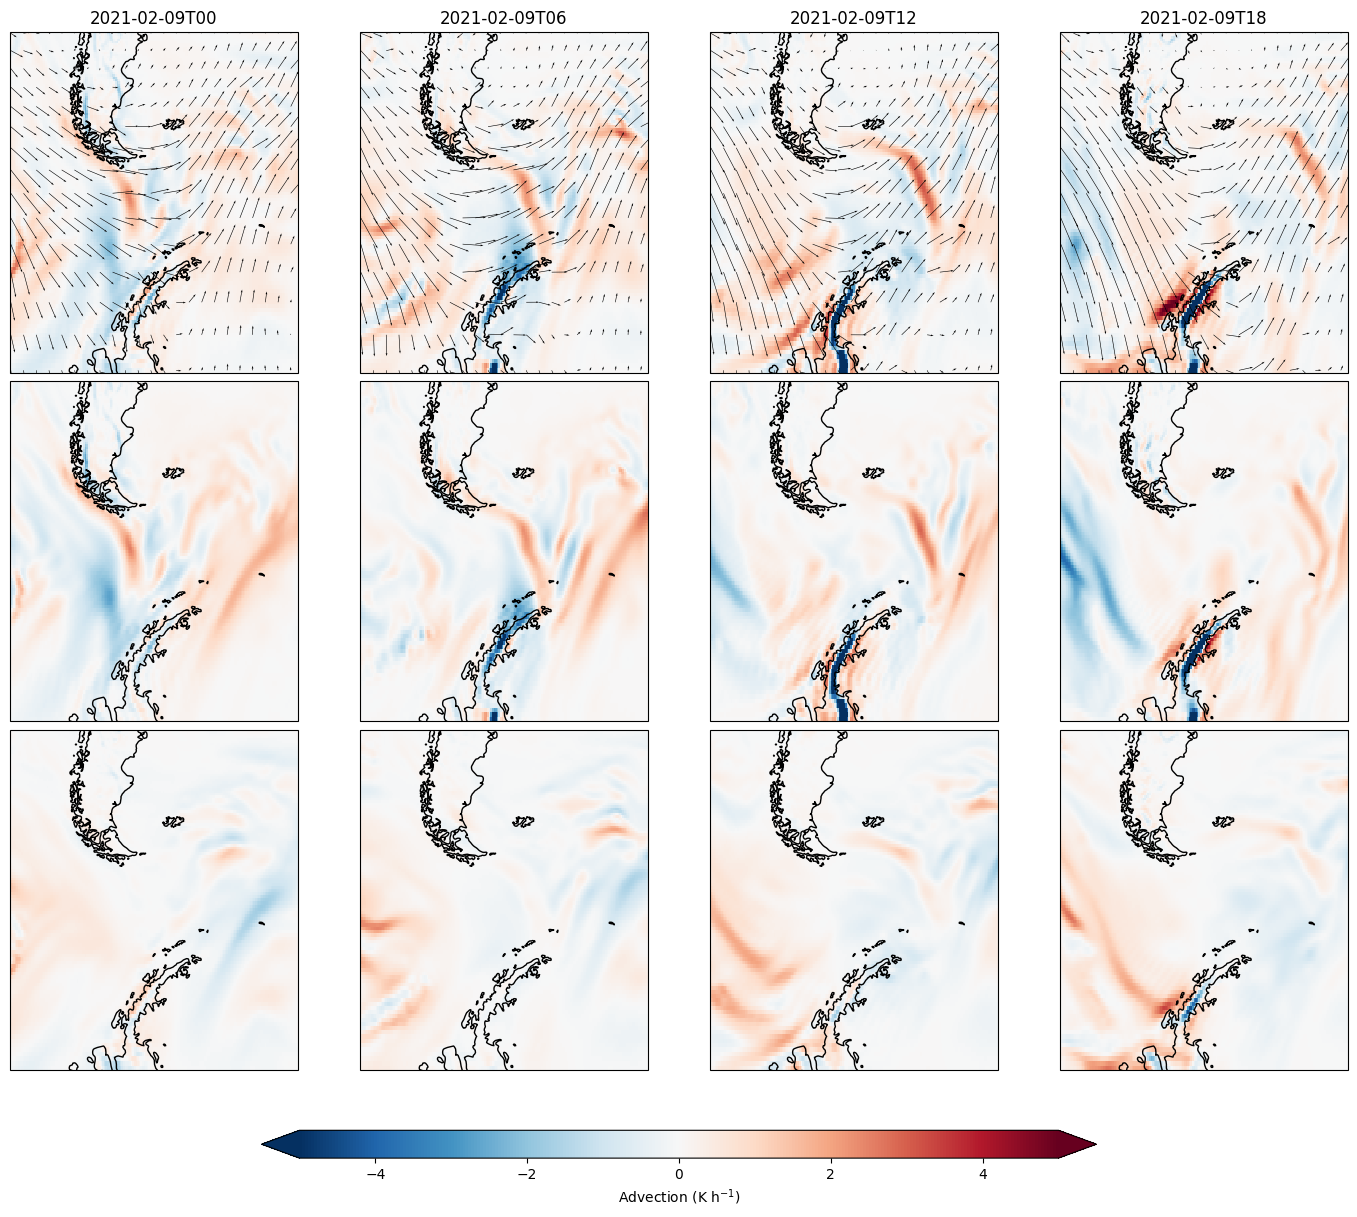

In [16]:
filename = "/home/lacrio/DATA/term_cal/res_new_700/era5_t_uvw_20210204_20210214_thermo_budget.nc"
ds = xr.open_dataset(filename) * 3600

filename = "/home/lacrio/DATA/term_cal/data_700/era5_t_uvw_20210204_20210214.nc"
ds_uv = xr.open_dataset(filename).sel(pressure_level=700)

date_sel = '2021-02-09'
times_h = [0,6,12,18]
# Select your day and 6-hourly times
# Select your day and 6-hourly times
adv_h = ds.sel(valid_time=date_sel)['adv_h']
adv_6h = adv_h.sel(valid_time=adv_h.valid_time.dt.hour.isin(times_h))

adv_x = ds.sel(valid_time=date_sel)['adv_x']
adv_x_6h = adv_x.sel(valid_time=adv_x.valid_time.dt.hour.isin(times_h))

adv_y = ds.sel(valid_time=date_sel)['adv_y']
adv_y_6h = adv_y.sel(valid_time=adv_y.valid_time.dt.hour.isin(times_h))

uv = ds_uv.sel(valid_time=date_sel)[['u','v']] 
uv_6h  = uv.sel(valid_time=uv.valid_time.dt.hour.isin(times_h))


# ---- FIX symmetric color limits ----
vmax = 5
vmin = -vmax

import numpy as np

# ---- Create subplots with projection ----
fig, axes = plt.subplots(
    3, 4, figsize=(14,12),
    subplot_kw={"projection": ccrs.Mercator()},
    constrained_layout=True
)

# ---- Loop por columnas (tiempo) ----
for i in range(4):

    # =====================
    # Fila 1: adv_h
    # =====================
    ax = axes[0, i]
    im = adv_6h.isel(valid_time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    
    ax.coastlines()
    
    # --- VECTORES ---
    skip = 8
    u_plot = uv_6h['u'].isel(valid_time=i)[::skip, ::skip]
    v_plot = uv_6h['v'].isel(valid_time=i)[::skip, ::skip]
    
    ax.quiver(
        u_plot.longitude.values,
        u_plot.latitude.values,
        u_plot.values,
        v_plot.values,
        transform=ccrs.PlateCarree(),
        scale=300,
        width=0.002
    )

    time_str = str(adv_6h.valid_time.values[i])[:13]
    ax.set_title(time_str)

    # =====================
    # Fila 2: adv_x
    # =====================
    ax = axes[1, i]
    adv_x_6h.isel(valid_time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title('')
    # =====================
    # Fila 3: adv_y
    # =====================
    ax = axes[2, i]
    adv_y_6h.isel(valid_time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title('')
# ---- Labels de filas ----
axes[0,0].set_ylabel("adv_h", fontsize=11)
axes[1,0].set_ylabel("adv_x", fontsize=11)
axes[2,0].set_ylabel("adv_y", fontsize=11)

# ---- One shared colorbar ----
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    pad=0.05,
    shrink=0.6,
    aspect=30,
    extend='both'
)
cbar.set_label("Advection (K h$^{-1}$)")

fig.savefig(
    "./fig/adv_2021.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()